# a better version of feedback simulator

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#data_dir = '/home/alexandresayal/mnt/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['UA']
hrf_delay = 0 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [3]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1'])

for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-psc_detrend.npy")
            tc = np.load(tc_file)

            # estimate percent signal change for each roi (mean = 100, variation relative to mean, as in TBV)
            # tc_0 = tc[:,0] / abs(np.mean(tc[:,0])) * 100
            # tc_1 = tc[:,1] / abs(np.mean(tc[:,1])) * 100
            # tc_2 = tc[:,2] / abs(np.mean(tc[:,2])) * 100
            # tc_3 = tc[:,3] / abs(np.mean(tc[:,3])) * 100

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

In [4]:
df

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1
0,sub-01,0.50,UA,"[-0.22502376, -0.75862014, -0.81892, 0.6557168...","[-0.29588887, -0.6328848, -1.0537118, -0.29287...","[0.007993267, 0.022420743, -0.31263652, -0.666...","[-0.061439723, -0.097172484, -0.0958057, -0.54...","[-0.26045632, -0.6957525, -0.9363159, 0.181421...","[-0.026723228, -0.03737587, -0.20422111, -0.60..."
1,sub-01,0.75,UA,"[-0.1484935, -0.16956916, 0.079313174, -0.1769...","[-0.14745189, -0.15049157, 0.3577576, 0.024255...","[0.06832045, 0.29584754, -1.2515142, -0.786156...","[-0.031186417, 0.1780903, -0.8298843, -0.43459...","[-0.1479727, -0.16003036, 0.2185354, -0.076326...","[0.018567018, 0.23696892, -1.0406992, -0.61037..."
2,sub-01,1.00,UA,"[0.031965997, -0.48273653, -0.8907577, 0.36385...","[0.061520167, 0.20370793, -0.8810853, 0.330087...","[-0.08184679, -0.25848472, -1.1230928, -0.5496...","[-0.018638223, 0.053932924, -0.9501851, -0.276...","[0.04674308, -0.1395143, -0.8859215, 0.3469732...","[-0.050242506, -0.1022759, -1.036639, -0.41311..."
3,sub-01,2.50,UA,"[-0.37241307, -0.5533644, -0.8987705, -0.64749...","[-0.5593146, -0.38626885, -0.79276997, 0.21441...","[-0.118400514, -0.6065576, -0.30131793, 1.4222...","[-0.13588795, -0.7827336, -0.43930644, 1.23786...","[-0.46586382, -0.46981663, -0.84577024, -0.216...","[-0.12714423, -0.69464564, -0.37031218, 1.3300..."
4,sub-02,0.50,UA,"[0.03159108, 0.39694837, -0.8714979, 0.0167620...","[0.09885405, 0.19240025, -0.51269156, -0.14231...","[0.18969432, 0.11383102, -0.111216284, 0.00378...","[0.2568193, 0.46569753, -0.478945, -0.5795565,...","[0.06522256, 0.2946743, -0.69209474, -0.062776...","[0.22325681, 0.28976429, -0.29508063, -0.28788..."
5,sub-02,0.75,UA,"[-0.050044052, -0.07861489, -0.61438787, -0.64...","[0.06749652, -0.097205535, -0.10130333, -0.269...","[-0.082796134, 0.078224994, -0.5599647, -0.421...","[-0.0523036, -0.099258624, -0.4690817, -0.7062...","[0.0087262355, -0.08791021, -0.3578456, -0.456...","[-0.06754987, -0.010516815, -0.5145232, -0.564..."
6,sub-02,1.00,UA,"[-0.09508178, -1.1542277, -1.1341574, -0.17950...","[0.14899692, -1.2343684, -0.9797818, -0.391660...","[0.038787037, -1.1393085, -0.7764846, -0.33127...","[0.25313842, -0.9710283, -0.63306755, -0.20025...","[0.026957572, -1.194298, -1.0569696, -0.285580...","[0.14596273, -1.0551684, -0.70477605, -0.26576..."
7,sub-02,2.50,UA,"[-0.1626477, 0.5250634, 0.9475856, -0.20723085...","[-0.10798834, -0.27678934, -0.82968324, -0.532...","[-0.02280507, 0.30654958, 0.6029477, -0.174165...","[-0.11606109, 0.86894715, 0.35739824, -0.04247...","[-0.13531801, 0.12413703, 0.05895117, -0.36967...","[-0.06943308, 0.58774835, 0.480173, -0.1083201..."
8,sub-03,0.50,UA,"[-0.1515789, -0.12747735, -0.65296406, -0.7728...","[-0.5010022, -0.7690687, -0.38646767, -0.52473...","[0.080002725, -0.2415044, -0.72874075, -1.1166...","[-0.08509719, 0.056116875, -0.30159146, -1.226...","[-0.32629055, -0.44827303, -0.51971585, -0.648...","[-0.0025472343, -0.09269376, -0.5151661, -1.17..."
9,sub-03,0.75,UA,"[0.38973752, -0.17533354, -0.42905602, -0.0456...","[0.14558744, -0.12060123, -0.089276835, -0.280...","[0.3205143, -0.0059788544, -1.1911408, -1.1389...","[0.052590087, -0.029729463, -0.76412183, -0.55...","[0.26766247, -0.14796738, -0.25916642, -0.1632...","[0.1865522, -0.017854158, -0.97763133, -0.8446..."


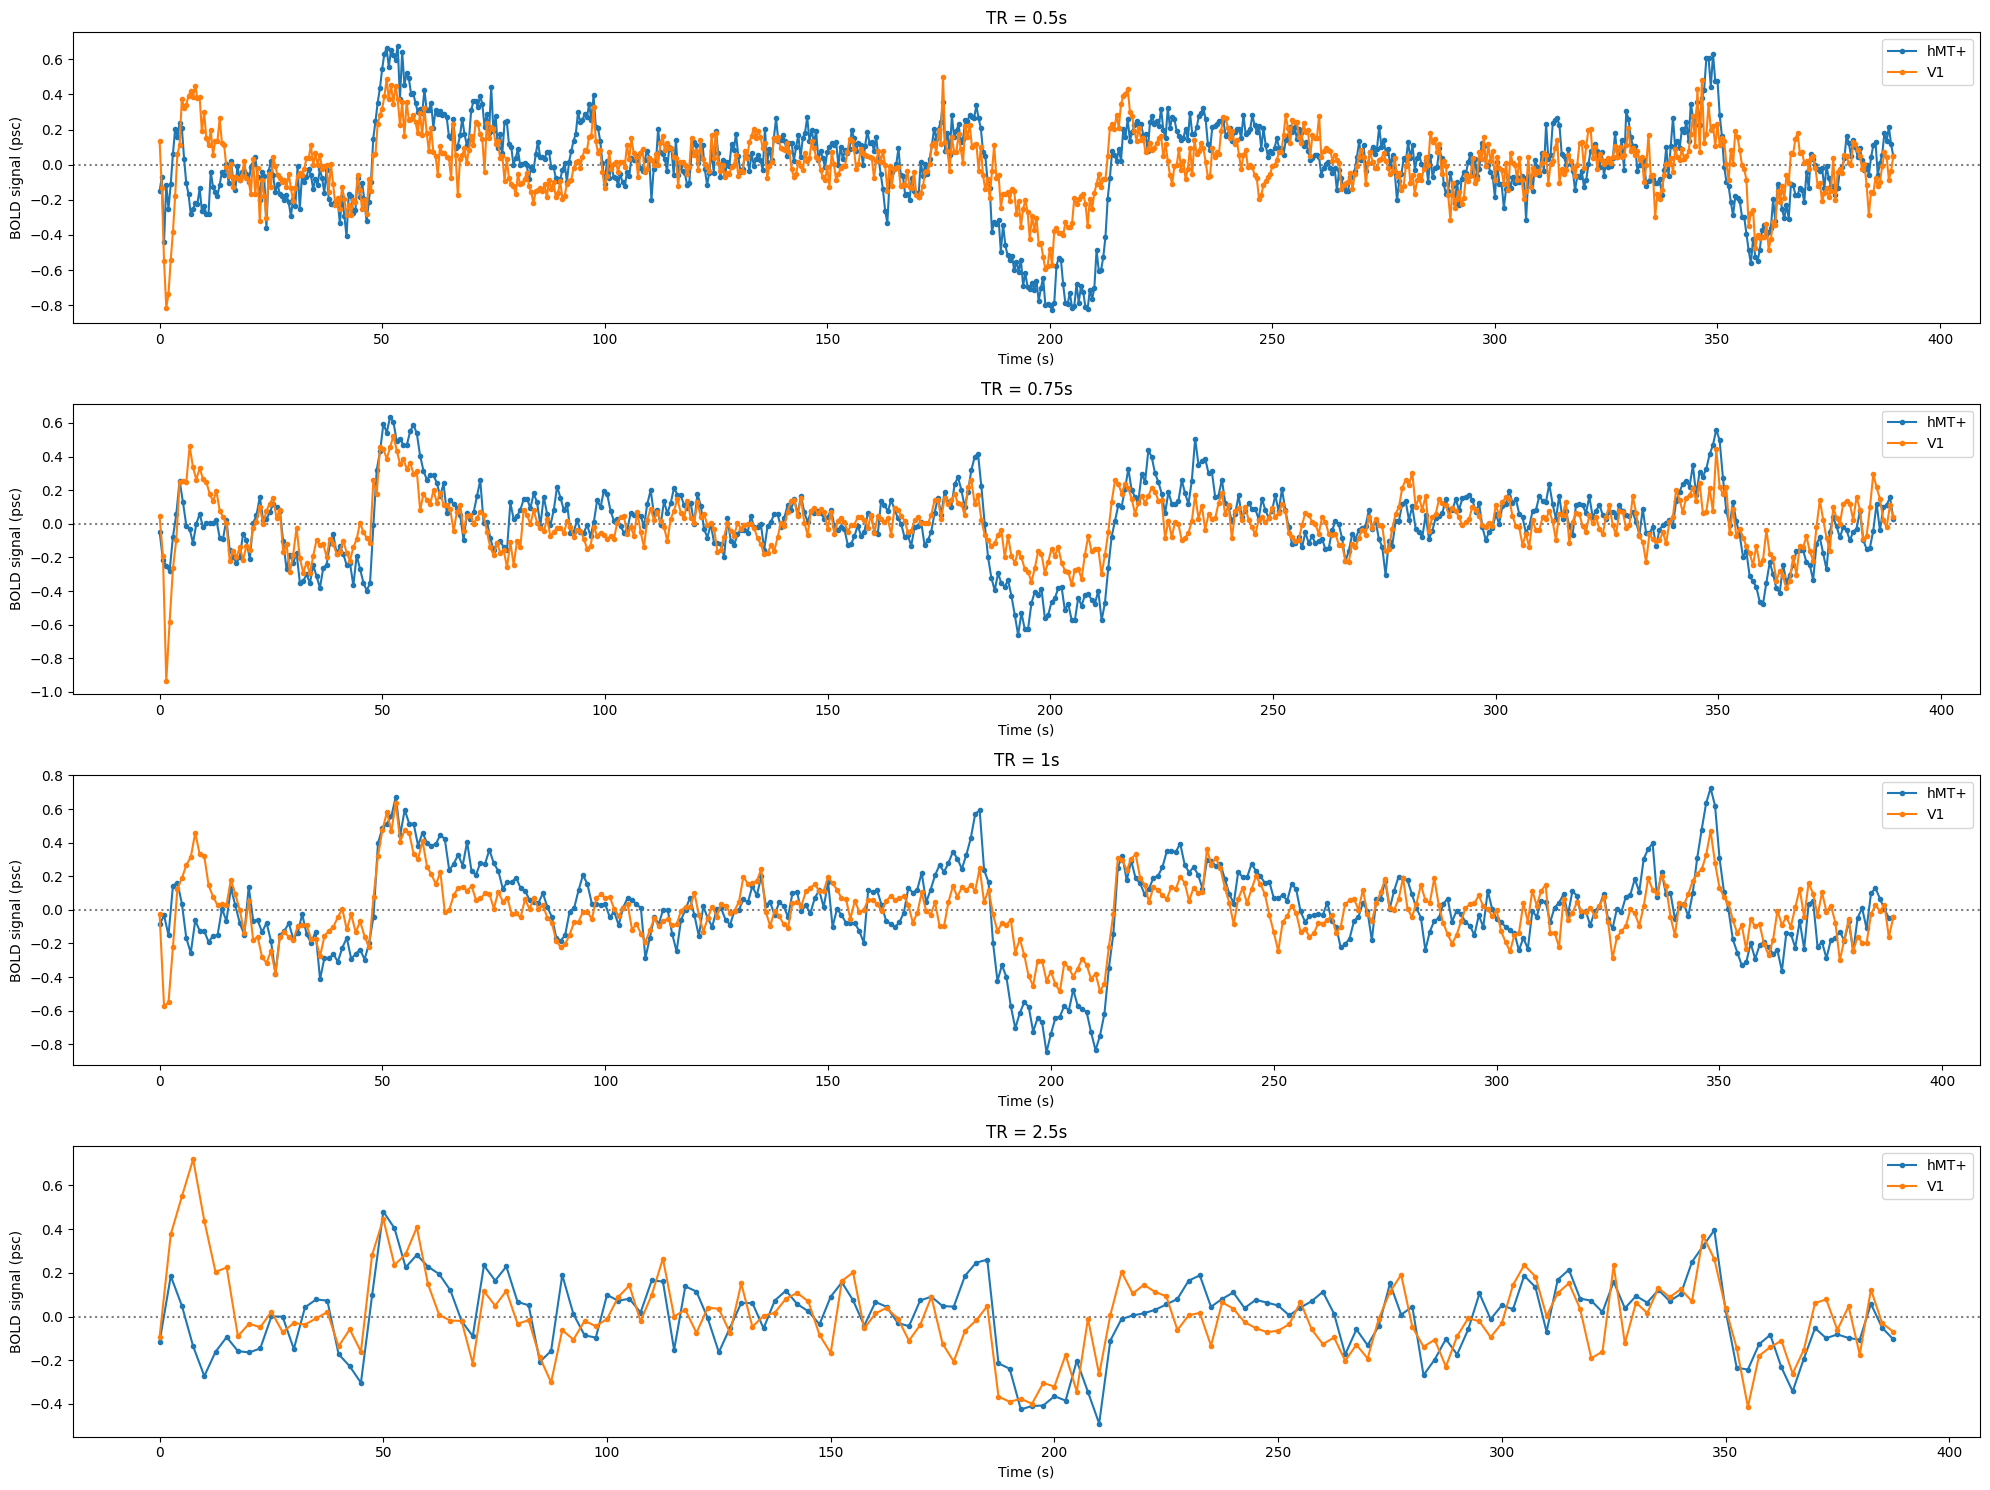

In [5]:
# Plot timecourses per TR
f, axs = plt.subplots(len(tr_list), 1, figsize=(20, 15))

for tr_idx, tr in enumerate(tr_list):

    n_volumes = n_volumes_list[tr_idx]

    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()
    m2 = df[df['tr']==tr]['bilateral_v1'].mean()
    s2 = df[df['tr']==tr]['bilateral_v1'].values.std()

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes*tr, tr)

    # add horizontal line at y=0
    axs[tr_idx].axhline(y=0, color='k', linestyle=':', alpha=0.5)

    # plot m1 and m2 in different colors with legend
    axs[tr_idx].plot(time_vector, m1, label='hMT+', marker='.')
    axs[tr_idx].plot(time_vector, m2, label='V1', marker='.')
    axs[tr_idx].legend()

    # plot the standard deviation as a shaded area
    #axs[tr_idx].fill_between(time_vector, m1-s1, m1+s1, alpha=0.2)
    #axs[tr_idx].fill_between(time_vector, m2-s2, m2+s2, alpha=0.2)

    # add title and axis labels
    axs[tr_idx].set_title('TR = ' + str(tr) + 's')
    axs[tr_idx].set_xlabel('Time (s)')
    axs[tr_idx].set_ylabel('BOLD signal (psc)')

plt.tight_layout()
plt.show()

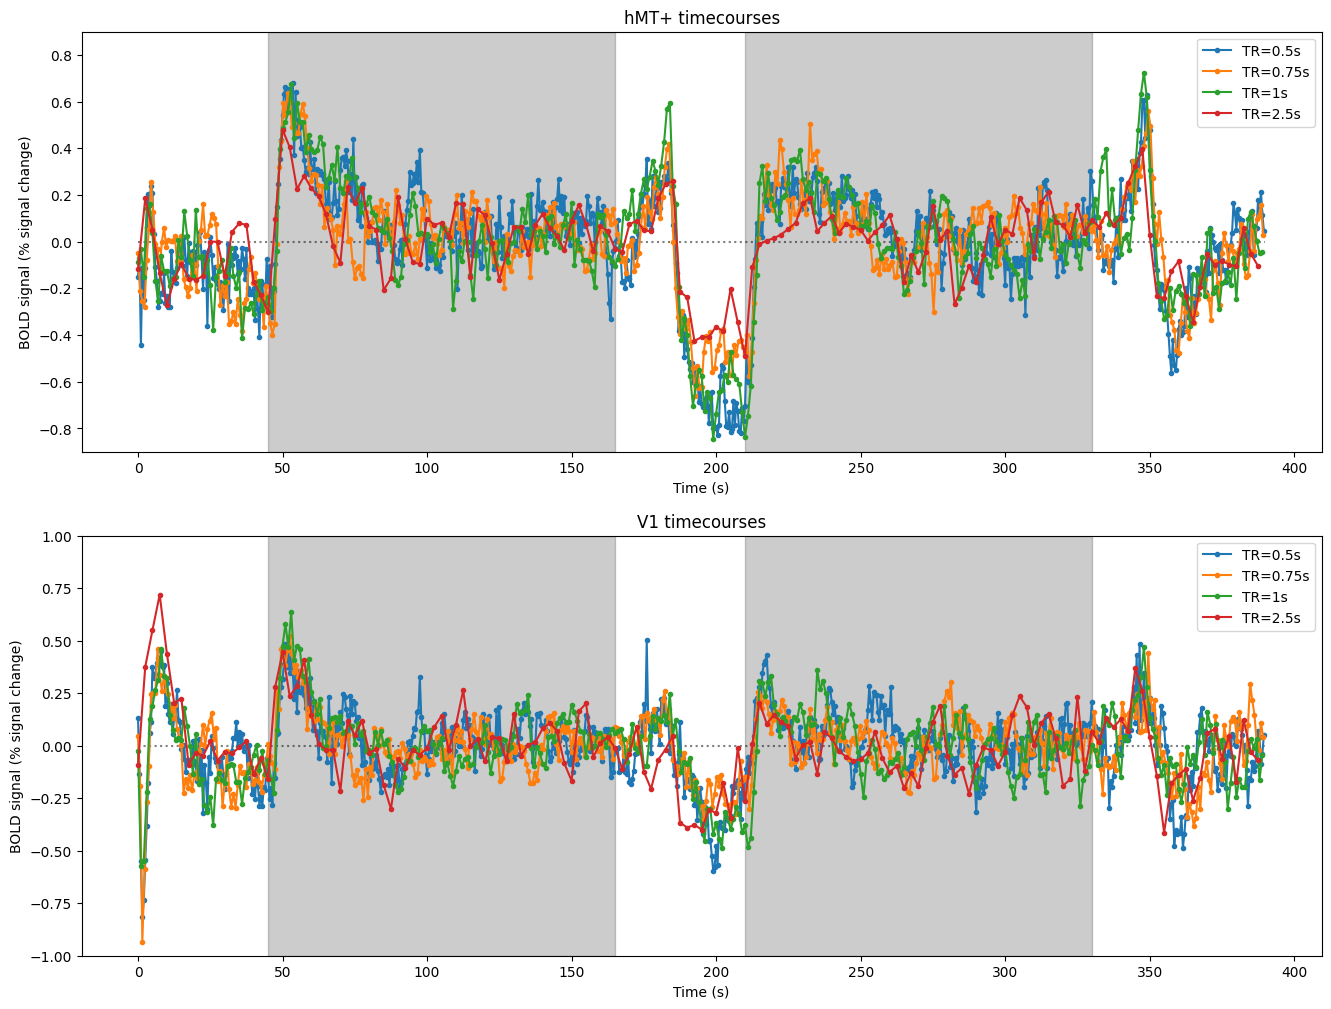

In [6]:
# Plot timecourses per ROI (bilateral_mt and bilateral_v1)
f, axs = plt.subplots(2, 1, figsize=(16, 12))

time_vectors = {}

# create time vectors for each TR
for tr_idx,tr in enumerate(tr_list):
    n_volumes = n_volumes_list[tr_idx]
    time_vectors[tr_idx] = np.arange(0, n_volumes*tr, tr)

axs[0].hlines(0, 0, 390, colors='k', linestyles=':', alpha=0.5)

# add colored background between x = 45 and 165 and 210 and 330
axs[0].axvspan(45, 165, alpha=0.2, color='k')
axs[0].axvspan(210, 330, alpha=0.2, color='k')

# plot hMT+ timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()

    axs[0].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s', marker='.')
    #axs[0].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[0].set_title('hMT+ timecourses')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('BOLD signal (% signal change)')
axs[0].set_ylim([-0.9, 0.9])
axs[0].legend()

axs[1].hlines(0, 0, 390, colors='k', linestyles=':', alpha=0.5)

# add colored background between x = 45 and 165 and 210 and 330
axs[1].axvspan(45, 165, alpha=0.2, color='k')
axs[1].axvspan(210, 330, alpha=0.2, color='k')

# plot V1 timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_v1'].mean()
    s1 = df[df['tr']==tr]['bilateral_v1'].values.std()

    axs[1].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s', marker='.')
    #axs[1].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[1].set_title('V1 timecourses')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('BOLD signal (% signal change)')
axs[1].set_ylim([-1, 1])
axs[1].legend()

plt.show()

# ERAs

In [7]:
import src.feedbackFunctions as ff

# Load sample events file per TR for sub-01
run_type = 'UA'
active_cond_name = 'motion'

static_events_indexes_arr = np.zeros((len(tr_list), 500))
active_events_indexes_arr = np.zeros((len(tr_list), 500))

for tr_idx,tr in enumerate(tr_list):

    task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
    events_file = os.path.join(data_dir, 'sub-01', 'func', f'sub-01_{task_label}_events.tsv')

    static_events_indexes, active_events_indexes = ff.read_events(events_file,hrf_delay,tr,active_cond_name)

    # exclude last block from static events
    aux = int(30/tr)
    static_events_indexes = static_events_indexes[:-aux]

    print(static_events_indexes)

    # save to array
    static_events_indexes_arr[tr_idx,:len(static_events_indexes)] = static_events_indexes
    active_events_indexes_arr[tr_idx,:len(active_events_indexes)] = active_events_indexes

verticalMarkers = np.array([15.5,45.5,164.5,179.5,209.5,329.5,344.5,374.5]) + hrf_delay # these mark the change of condition (including hrf_delay)

[ 30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  88  89  90  91 360 361 362 363 364 365 366 367 368 369
 370 371 372 373 374 375 376 377 378 379 380 381 382 383 384 385 386 387
 388 389 390 391 392 393 394 395 396 397 398 399 400 401 402 403 404 405
 406 407 408 409 410 411 412 413 414 415 416 417 418 419]
[ 20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60 240 241 242 243 244 245 246 247 248 249 250 251 252
 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270
 271 272 273 274 275 276 277 278 279]
[ 15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32
  33  34  35  36  37  38  39  40  41  42  43  44  45 180 181 182 183 184
 185 186 187 188 189 190 191

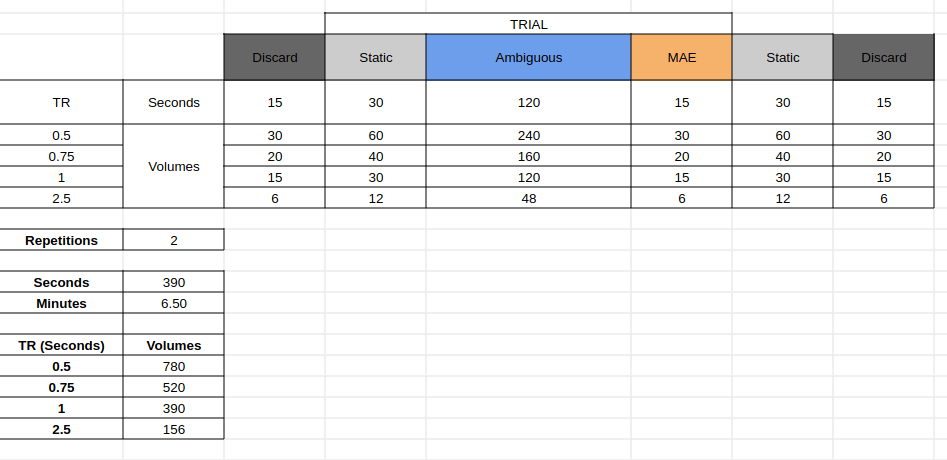

(15, 780)
(15,)
(15, 520)
(15,)
(15, 390)
(15,)
(15, 156)
(15,)


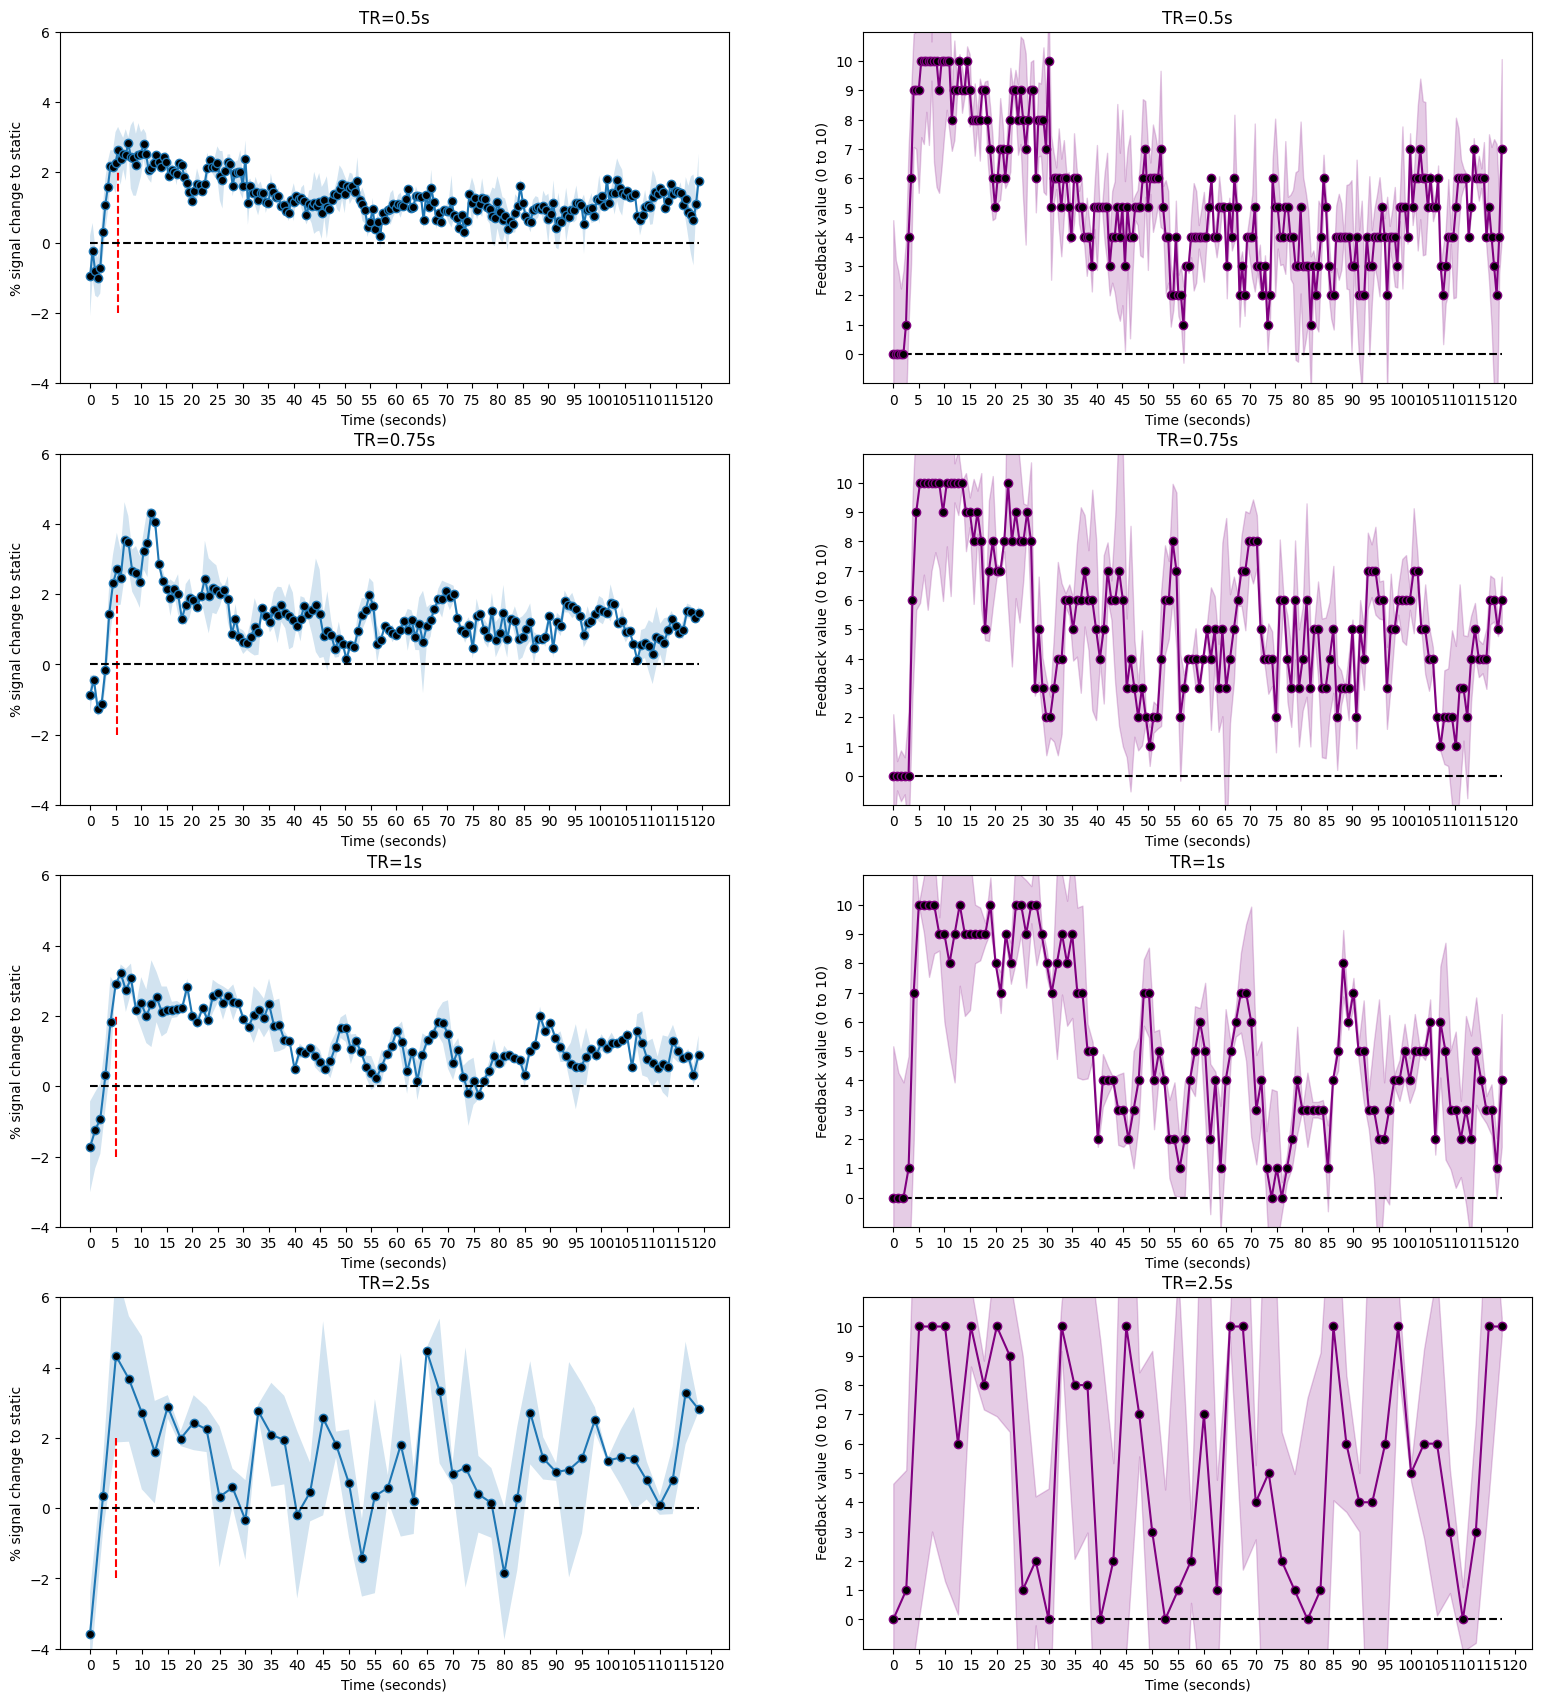

In [9]:
# plot ERA with mean PSC to static timeseries for each tr
f_psc, axs_psc = plt.subplots(4, 2, figsize=(19, 21))
roi_name = 'bilateral_mt'

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros (a big array was initialized)
    static_events_indexes_aux = static_events_indexes_arr[tr_idx, static_events_indexes_arr[tr_idx,:] != 0]
    active_events_indexes_aux = active_events_indexes_arr[tr_idx, active_events_indexes_arr[tr_idx,:] != 0]


    # ----------------------------------------------------------------------------
    time_series = df[df['tr']==tr][roi_name].values
    time_series = np.stack(time_series, axis=0)

    print(time_series.shape)

    time_series_static = time_series[:,static_events_indexes_aux.astype(int)]

    m_s = np.mean(time_series_static,axis=1)

    print(m_s.shape)

    time_series_psc = time_series.copy()
    for i in range(time_series_psc.shape[0]):
        time_series_psc[i,:] = (time_series[i,:] - m_s[i]) / abs(m_s[i])

    # all values greater than 5 are set to 5, all values lower than 0 are set to 0
    time_series_disc = time_series_psc.copy()

    time_series_disc = np.round(time_series_disc*4) # conversion to 10 levels considering a max PSC of 2.5

    # ----------------------------------------------------------------------------
    # estimate mean and std of time series across subjects

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)
    time_series_disc_mean = time_series_disc.mean(axis=0)
    time_series_disc_std = time_series_disc.std(axis=0)

    # estimate event related response
    time_series_mean_active = time_series_mean[active_events_indexes_aux.astype(int)]
    time_series_disc_mean_active = time_series_disc_mean[active_events_indexes_aux.astype(int)]
    time_series_mean_active_length = time_series_mean_active.shape[0]//2

    # reshape time_series_mean_active to two columns with half the points each
    time_series_mean_active = time_series_mean_active.reshape((2,time_series_mean_active_length)).T
    time_series_disc_mean_active = time_series_disc_mean_active.reshape((2,time_series_mean_active_length)).T

    # estimate mean and std
    time_series_mean_psc_active_mean = time_series_mean_active.mean(axis=1)
    time_series_mean_psc_active_std = time_series_mean_active.std(axis=1)
    time_series_disc_mean_psc_active_mean = time_series_disc_mean_active.mean(axis=1)
    time_series_disc_mean_psc_active_std = time_series_disc_mean_active.std(axis=1)

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, time_series_mean_active_length*tr, tr)

    data_to_plot_mean = time_series_mean_psc_active_mean
    data_to_plot_std = time_series_mean_psc_active_std

    # add lines in the first point above y=2.5
    axs_psc[tr_idx,0].vlines(time_vector[data_to_plot_mean >= 2.5][0], -2, 2, color='r', linestyles='dashed')

    # plot mean and std timeseries
    axs_psc[tr_idx,0].plot(time_vector, data_to_plot_mean, marker = 'o', markerfacecolor = 'black')
    axs_psc[tr_idx,0].fill_between(time_vector, data_to_plot_mean-data_to_plot_std, data_to_plot_mean+data_to_plot_std, alpha=0.2)
    axs_psc[tr_idx,0].hlines(0, 0, time_vector[-1], colors='k', linestyles='dashed')

    axs_psc[tr_idx,0].set_title(f'TR='+str(tr)+'s')
    axs_psc[tr_idx,0].set_xlabel('Time (seconds)')
    axs_psc[tr_idx,0].set_ylabel('% signal change to static')
    axs_psc[tr_idx,0].set_xticks(np.arange(0,121,5))
    axs_psc[tr_idx,0].set_ylim([-4, 6])

    # set maximums and round
    time_series_disc_mean_psc_active_mean[time_series_disc_mean_psc_active_mean > 10] = 10
    time_series_disc_mean_psc_active_mean[time_series_disc_mean_psc_active_mean < 0] = 0
    time_series_disc_mean_psc_active_mean = np.round(time_series_disc_mean_psc_active_mean)

    # plot 2nd column
    axs_psc[tr_idx,1].hlines(0, 0, time_vector[-1], colors='k', linestyles='dashed')
    axs_psc[tr_idx,1].plot(time_vector, time_series_disc_mean_psc_active_mean, marker = 'o', markerfacecolor = 'black', color='purple')
    axs_psc[tr_idx,1].fill_between(time_vector, time_series_disc_mean_psc_active_mean-time_series_disc_mean_psc_active_std, time_series_disc_mean_psc_active_mean+time_series_disc_mean_psc_active_std, alpha=0.2, color='purple')
    axs_psc[tr_idx,1].set_ylim([-1, 11])
    axs_psc[tr_idx,1].set_title(f'TR='+str(tr)+'s')
    axs_psc[tr_idx,1].set_xlabel('Time (seconds)')
    axs_psc[tr_idx,1].set_ylabel('Feedback value (0 to 10)')
    axs_psc[tr_idx,1].set_xticks(np.arange(0,121,5))
    axs_psc[tr_idx,1].set_yticks(np.arange(0,11,1))
